
## IND320 – Data to Decision
###  Project Work – Part 1
### Syed Muhammad Murtaza Zaidi

The purpose of this notebook is to document the tasks done for this project including data preparation and exploratory analysis carried out as the foundation for the Reservoir Streamlit application.


## Project Links

**GitHub Repository:**  
https://github.com/SP18-BCS-156/IND320-Project

**Streamlit Application:**
https://ind320-project.streamlit.app/


**ScreenCast**
https://github.com/SP18-BCS-156/IND320-Project/blob/main/IND-320%20Project%20Part%201.webm

## 1. AI Usage
AI tools were used as development assistants throughout this project.

The assistance included:

* clarifying the assignment requirements,
* suggesting a logical structure for the Jupyter Notebook,
* explaining Pandas and Streamlit functionality,
* improving code comments and documentation,
* assisting with debugging and troubleshooting, and
* reviewing the code for readability and reproducibility.

All AI-generated suggestions were reviewed, evaluated, and adapted before being incorporated into the project. The data analysis, implementation choices, testing, and final submission were carried out under my responsibility.



## 2. Project Overview - Streamlit Application

The Reservoir Streamlit application provides an interactive interface for exploring Norwegian reservoir data.

The application contains four pages:

1. **Home:** Introduces ReservoirScope and provides navigation.
2. **Data Representation:** Displays the imported dataset and first-month reservoir measurements using Streamlit's `LineChartColumn()`.
3. **Visualisation:** Provides interactive variable selection, month-range filtering and time-series visualisation.
4. **Project Information:** Documents the project objectives, features, technologies and data processing.

The application reads the local CSV file using Pandas and uses `st.cache_data` to improve data-loading performance.

The interactive visualisation uses national reservoir observations. Min-Max normalisation is applied when comparing measurements with different numerical scales. Constant variables are handled separately to avoid division by zero.

The source code is hosted on GitHub, and the application is publicly accessible through Streamlit Community Cloud.


## 3. Tasks - Imports

We uses Pandas for data manipulation and Matplotlib for visualisation.


In [61]:
# Import Pandas for loading, inspecting, and manipulating tabular data.
import pandas as pd

# Import Matplotlib for creating static visualisations in the notebook.
import matplotlib.pyplot as plt

## 4. Dataset loading

The  dataset is stored locally in `reservoirs.csv`.
It is loaded into a Pandas DataFrame so that the data can be inspected,
cleaned, transformed, and visualised.

In [62]:
# Load the local CSV file into a Pandas DataFrame.
reservior_df = pd.read_csv("reservoirs.csv")

# Display the first five rows to confirm that the file was loaded correctly.
reservior_df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 5.Dataset Inspection

For Dataset Inspection

We inspect:

- the number of rows and columns,
- original column names,
- data types,
- missing values,
- duplicate rows,
- and a sample of the observations.

This step helps identify any cleaning or preparation required before analysis.

In [63]:
# Show the dimensions of the dataframe
reservior_df.shape

(14877, 11)

In [64]:
# Display the original column names exactly as they appear in the CSV file.
print("Original columns:")
for column in reservior_df.columns:
    print("-", column)

Original columns:
- dato_Id
- omrType
- omrnr
- iso_aar
- iso_uke
- fyllingsgrad
- kapasitet_TWh
- fylling_TWh
- neste_Publiseringsdato
- fyllingsgrad_forrige_uke
- endring_fyllingsgrad


In [65]:
# Display the data type and number of non-null values for each column.
reservior_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  object 
 1   omrType                   14877 non-null  object 
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  object 
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 1.2+ MB


In [66]:
# Check missing values
reservior_df.isnull().sum()

dato_Id                     0
omrType                     0
omrnr                       0
iso_aar                     0
iso_uke                     0
fyllingsgrad                0
kapasitet_TWh               0
fylling_TWh                 0
neste_Publiseringsdato      0
fyllingsgrad_forrige_uke    0
endring_fyllingsgrad        0
dtype: int64

In [67]:
# Count fully duplicated rows in the dataset.
duplicate_count = reservior_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [68]:
# Display a small sample of the raw dataset.
reservior_df.head(10)

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


## 6. Rename headers to English and understandable.

The original dataset has Norwegian variable names.

Only the column labels are changed to English

In [69]:
# Rename Norwegian column names to descriptive English equivalents.
reservior_df = reservior_df.rename(
    columns = {
        'dato_Id': "date",
        'omrType': "area_type",
        'omrnr': "area_number",
        'iso_aar': "year",
        'iso_uke': "week",
        'fyllingsgrad': "fill_level",
        'kapasitet_TWh': "capacity_TWh",
        'fylling_TWh': "stored_energy_TWh",
        'neste_Publiseringsdato': "next_publication_date",
        'fyllingsgrad_forrige_uke': "previous_week_fill_level",
        'endring_fyllingsgrad': "change_in_fill_level"
    }
)

# Inspecting that the column names have been updated.
reservior_df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 7. Data Preparation

DateTime Conversion

In [70]:
# Convert the observation date into a Pandas datetime object.
reservior_df["date"] = pd.to_datetime(reservior_df["date"])



Publication Date Placeholders


In [71]:
# Count placeholder publication dates.
placeholder_count = (
    reservior_df["next_publication_date"]
    == "0001-01-01T00:00:00"
).sum()

print(f"Placeholder publication dates: {placeholder_count:,}")

# Replace placeholder dates with missing values.
reservior_df["next_publication_date"] = (
    reservior_df["next_publication_date"]
    .replace("0001-01-01T00:00:00", pd.NA)
)

# Convert the remaining publication dates to datetime.
reservior_df["next_publication_date"] = pd.to_datetime(
    reservior_df["next_publication_date"],
    errors="coerce"
)

# Inspect the data types.
reservior_df.dtypes

Placeholder publication dates: 11,322


date                        datetime64[ns]
area_type                           object
area_number                          int64
year                                 int64
week                                 int64
fill_level                         float64
capacity_TWh                       float64
stored_energy_TWh                  float64
next_publication_date       datetime64[ns]
previous_week_fill_level           float64
change_in_fill_level               float64
dtype: object

In [72]:
# Check whether either date column contains missing values.
date_missing = reservior_df[
    ["date", "next_publication_date"]
].isna().sum()

date_missing

date                         0
next_publication_date    11322
dtype: int64

Chronological Ordering


In [73]:
# Sort observations chronologically and reset the row index.
reservior_df = reservior_df.sort_values("date").reset_index(drop=True)

# Display the earliest observations after sorting.
reservior_df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,NaT,0.614288,0.002160
1,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,NaT,0.801348,-0.242484
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,NaT,0.596027,0.006349
3,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,NaT,0.734888,-0.113421
4,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,NaT,0.777604,-0.146657


## 8. Data Representation

In [74]:
# Summarise the main characteristics of the dataset.
print(f"Number of observations: {len(reservior_df):,}")
print(f"Start date: {reservior_df['date'].min().date()}")
print(f"End date: {reservior_df['date'].max().date()}")
print(f"Number of years represented: {reservior_df['year'].nunique()}")
print(f"Area types: {sorted(reservior_df['area_type'].dropna().unique())}")

# Convert area numbers to standard Python integers.
area_numbers = sorted(
    int(value)
    for value in reservior_df["area_number"].dropna().unique()
)

print(f"Area numbers: {area_numbers}")


Number of observations: 14,877
Start date: 1995-01-08
End date: 2026-09-06
Number of years represented: 32
Area types: ['EL', 'NO', 'VASS']
Area numbers: [0, 1, 2, 3, 4, 5]


## 9. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution and
structure of the reservoir variables before they are visualised in the
Streamlit application.

The analysis focuses on:

- descriptive statistics,
- categorical distributions,
- ranges of reservoir measurements,
- and changes over time.

The goal is exploratory understanding rather than predictive modelling.

In [75]:
# display statistics
reservior_df.describe()

,date,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_fill_level,change_in_fill_level
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,3555,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,2022-12-07 13:21:52.405063168,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,2019-02-27 13:00:00,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,2021-01-13 13:00:00,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,2022-12-07 13:00:00,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,2024-10-30 13:00:00,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,2026-09-16 13:00:00,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,NaN,0.214843,0.031385


### 9.1 Area Types


In [76]:
# Count the number of observations for each area type.
area_type_counts = reservior_df["area_type"].value_counts()

area_type_counts

area_type
EL      8265
VASS    4959
NO      1653
Name: count, dtype: int64

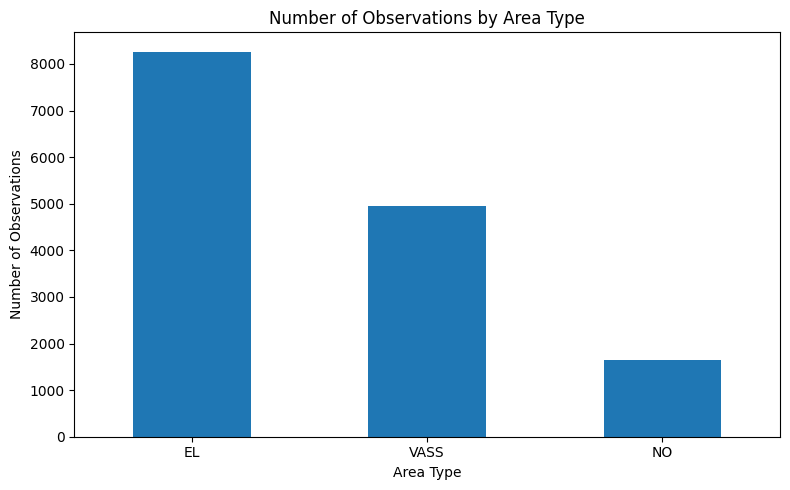

In [77]:
# Visualise the number of observations for each area type.
area_type_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Observations by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9.2 Area Numbers

The distribution of observations across `area_number` is examined to identify
the geographical units represented in the dataset.

In [78]:
# Count observations for each area number.
area_number_counts = (
    reservior_df["area_number"]
    .value_counts()
    .sort_index()
)

area_number_counts

area_number
0    1653
1    3306
2    3306
3    3306
4    1653
5    1653
Name: count, dtype: int64

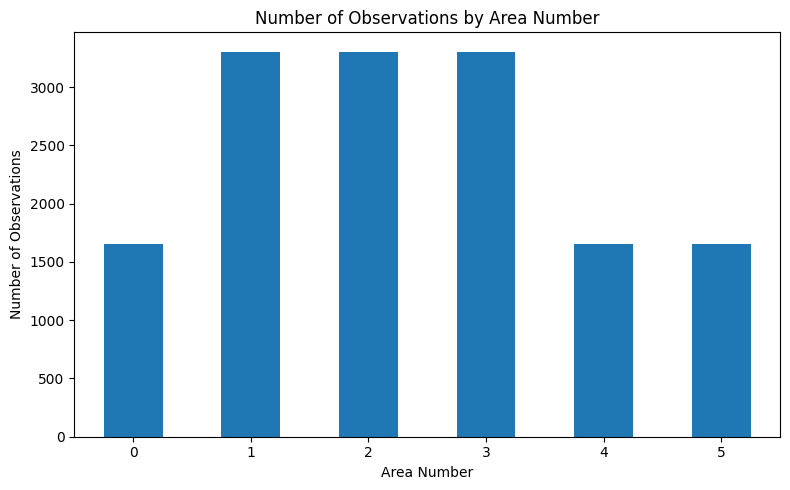

In [79]:
# Plot the number of records associated with each area number.
area_number_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Observations by Area Number")
plt.xlabel("Area Number")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9.3 Year Distribution

A bar chart is used to show the number of observations recorded in each year.

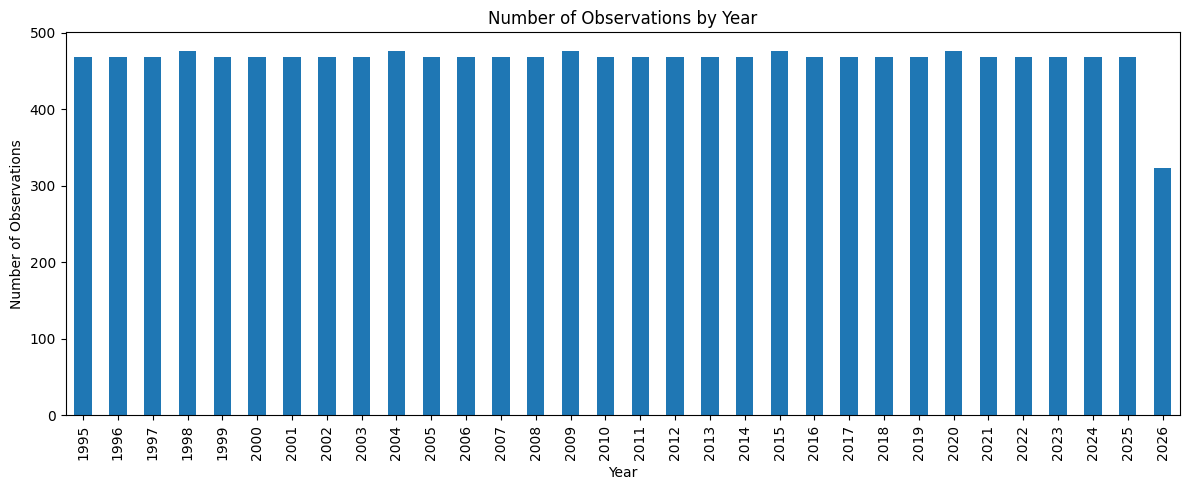

In [80]:
# Plot the number of observations for each year.
year_counts = reservior_df["year"].value_counts().sort_index()

year_counts.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Number of Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()



### 9.4 Week Distribution

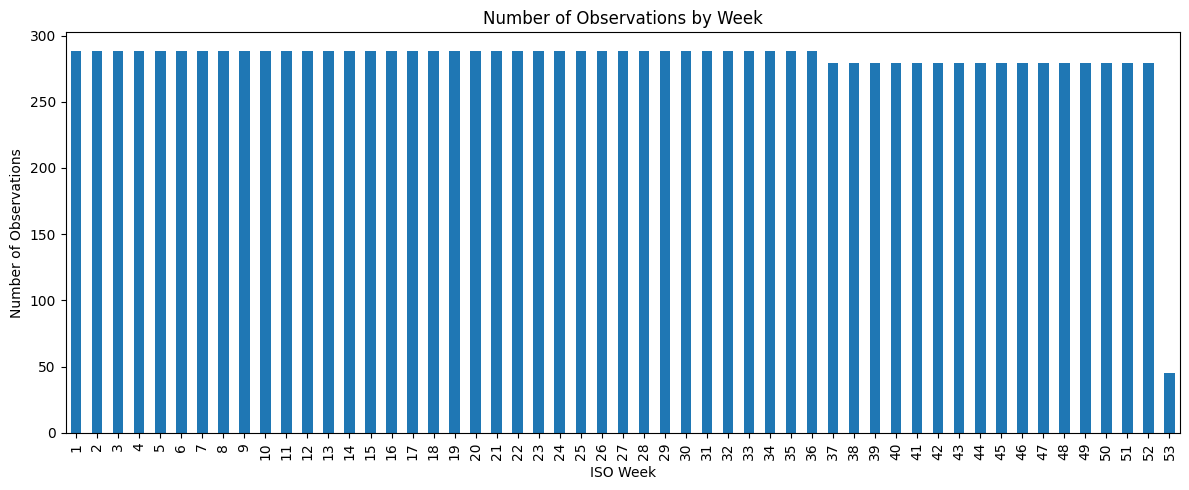

In [81]:
# Plot the number of observations for each week.
week_counts = reservior_df["week"].value_counts().sort_index()

week_counts.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Number of Observations by Week")
plt.xlabel("ISO Week")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

### 9.5 Reservoir  Variables


In [82]:
# Define the continuous reservoir variables used in the main visualisations.
measurement_columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "previous_week_fill_level",
    "change_in_fill_level",
]

# Display descriptive statistics for these variables only.
reservior_df[measurement_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
fill_level,14877.0,0.618852,0.214850,0.055160,0.456234,0.648049,0.802135,1.020072
capacity_TWh,14877.0,29.145860,22.739070,6.003264,17.390587,23.237715,34.043590,87.437580
stored_energy_TWh,14877.0,18.139713,15.966211,0.331142,7.321973,14.501389,22.203530,84.544820
previous_week_fill_level,14877.0,0.618890,0.214843,0.055160,0.456356,0.648114,0.802133,1.020037
change_in_fill_level,14877.0,-0.000038,0.031385,-0.242484,-0.022395,-0.007072,0.016277,0.336623


## 10. Individual Variable Visualisations




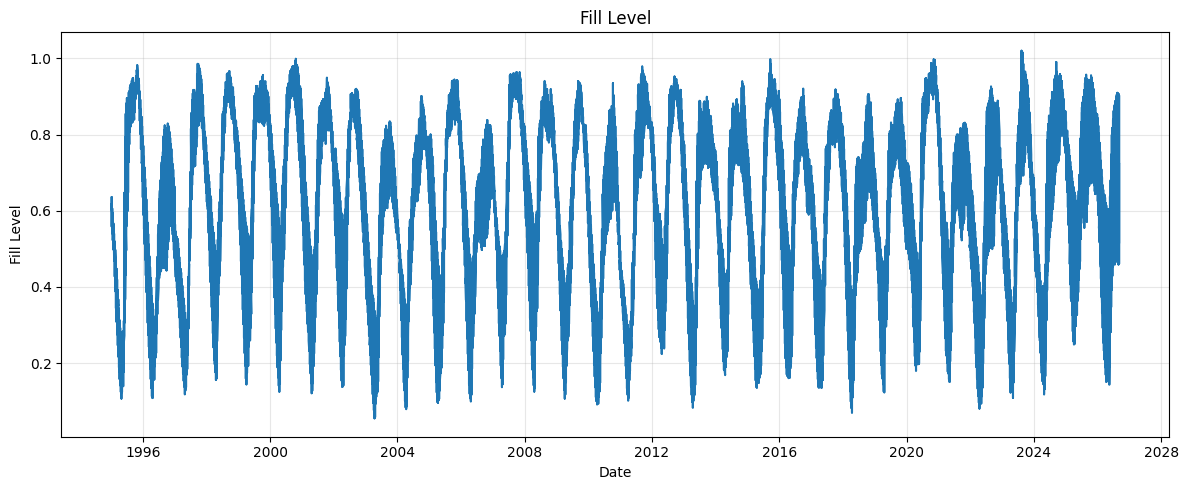

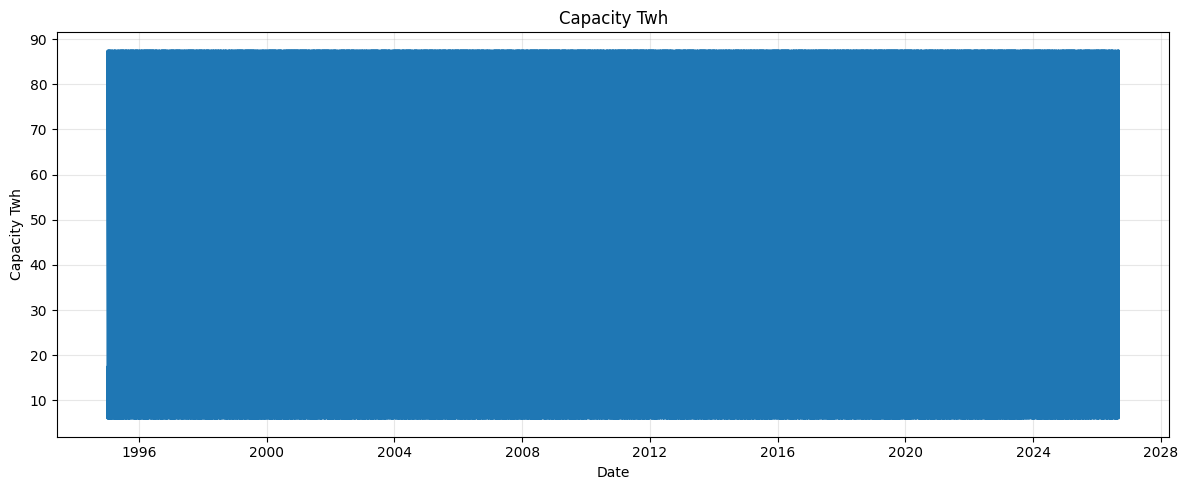

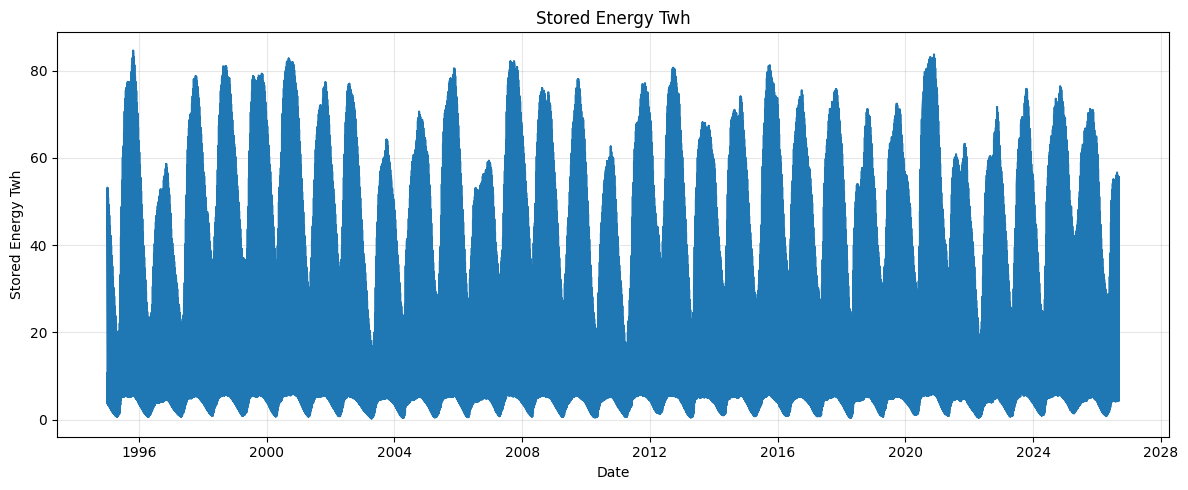

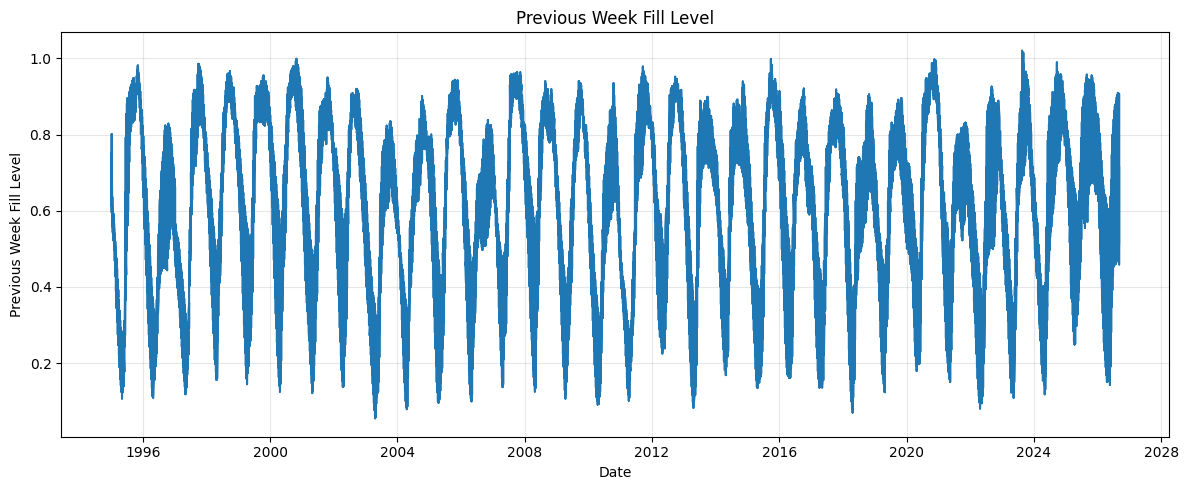

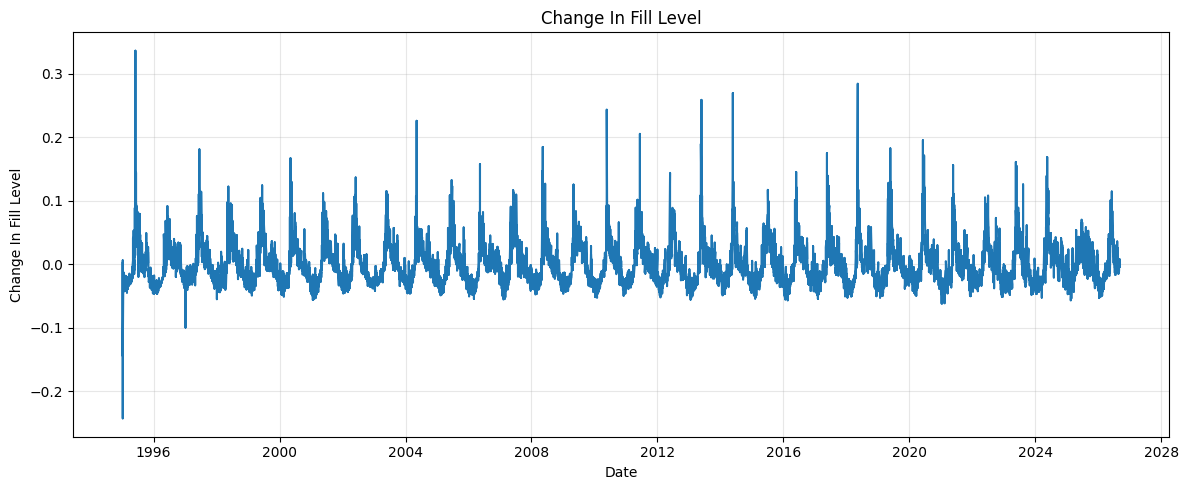

In [83]:
# Plot each continuous reservoir measurement in its own figure.
for column in measurement_columns:
    plt.figure(figsize=(12, 5))

    plt.plot(
        reservior_df["date"],
        reservior_df[column]
    )

    plt.title(column.replace("_", " ").title())
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 11 Aggregated Time Series


In [84]:
# Select the national reservoir data.
national_df = reservior_df[
    (reservior_df["area_type"] == "NO")
    & (reservior_df["area_number"] == 0)
].copy()

# Calculate the mean for each date.
weekly_mean = (
    national_df.groupby("date")[measurement_columns]
    .mean()
    .sort_index()
)

weekly_mean.head()

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
date,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


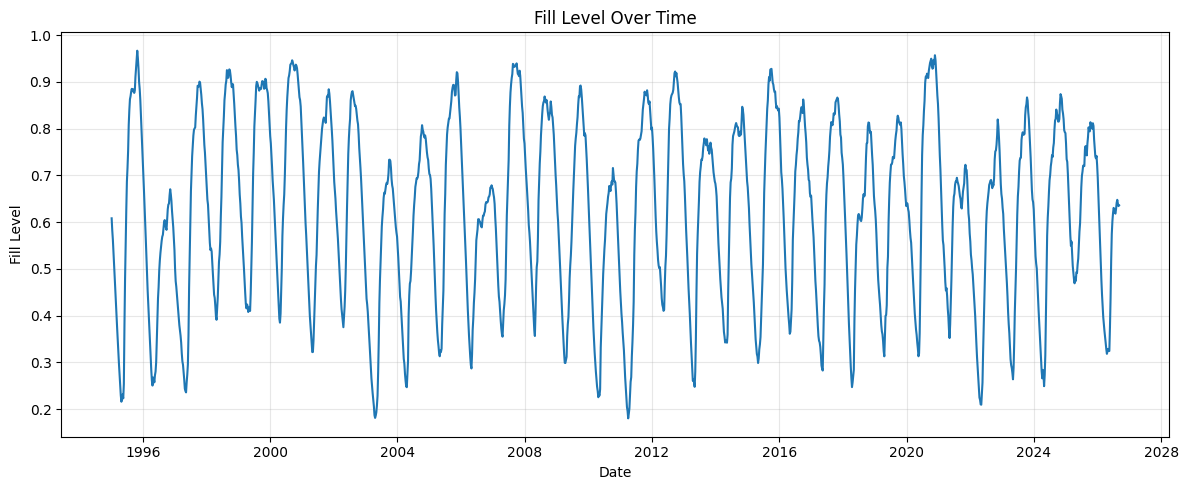

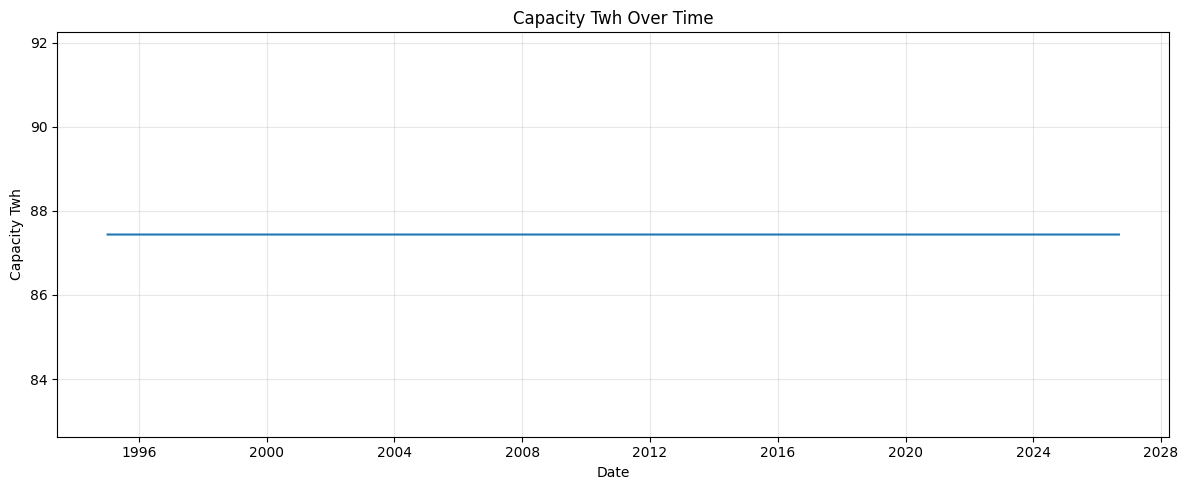

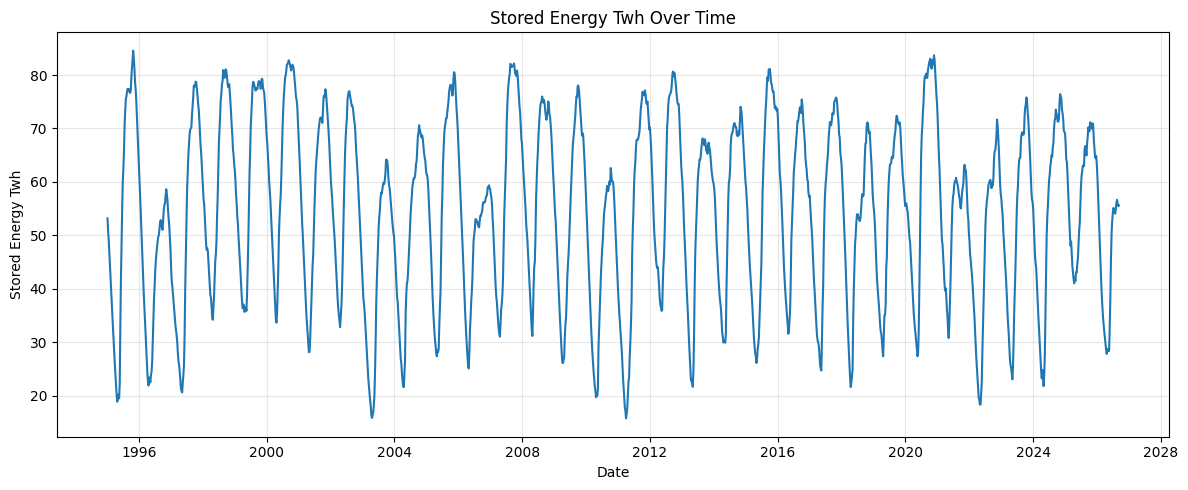

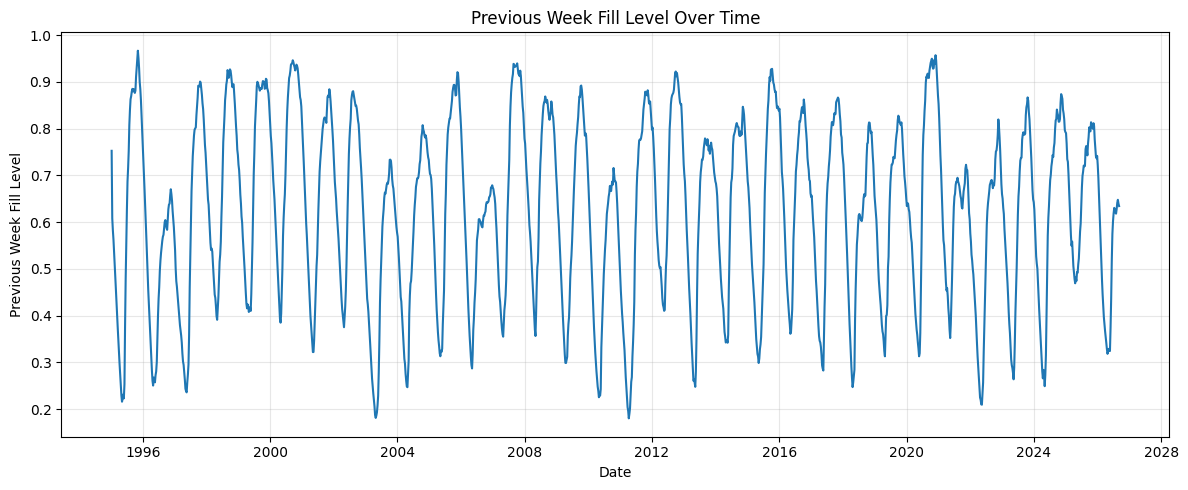

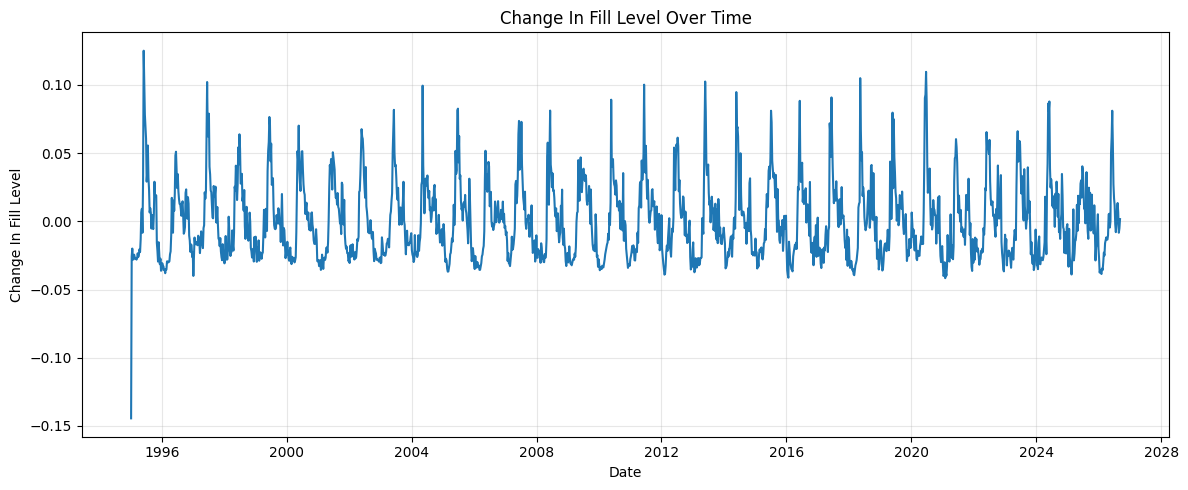

In [85]:
# Plot each aggregated measurement as a separate time series.
for column in measurement_columns:
    plt.figure(figsize=(12, 5))

    plt.plot(
        weekly_mean.index,
        weekly_mean[column]
    )

    plt.title(f"{column.replace('_', ' ').title()} Over Time")
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 12. Combined Visualisation

The transformation is used only for this combined visualisation. The original data remain unchanged.


In [86]:
# Apply Min-Max normalisation independently to each measurement column.
normalized_weekly_mean = (
    (weekly_mean - weekly_mean.min())
    / (weekly_mean.max() - weekly_mean.min()).replace(0, float("nan"))
)

# Assign 0.5 to variables with constant values.
normalized_weekly_mean = normalized_weekly_mean.fillna(0.5)

normalized_weekly_mean.head()

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
date,,,,,
1995-01-08,0.544098,0.5,0.544098,0.727714,0.000000
1995-01-15,0.511173,0.5,0.511173,0.544109,0.439810
1995-01-22,0.485800,0.5,0.485800,0.511204,0.461793
1995-01-29,0.450329,0.5,0.450329,0.485808,0.432379
1995-02-05,0.414707,0.5,0.414707,0.450310,0.432013


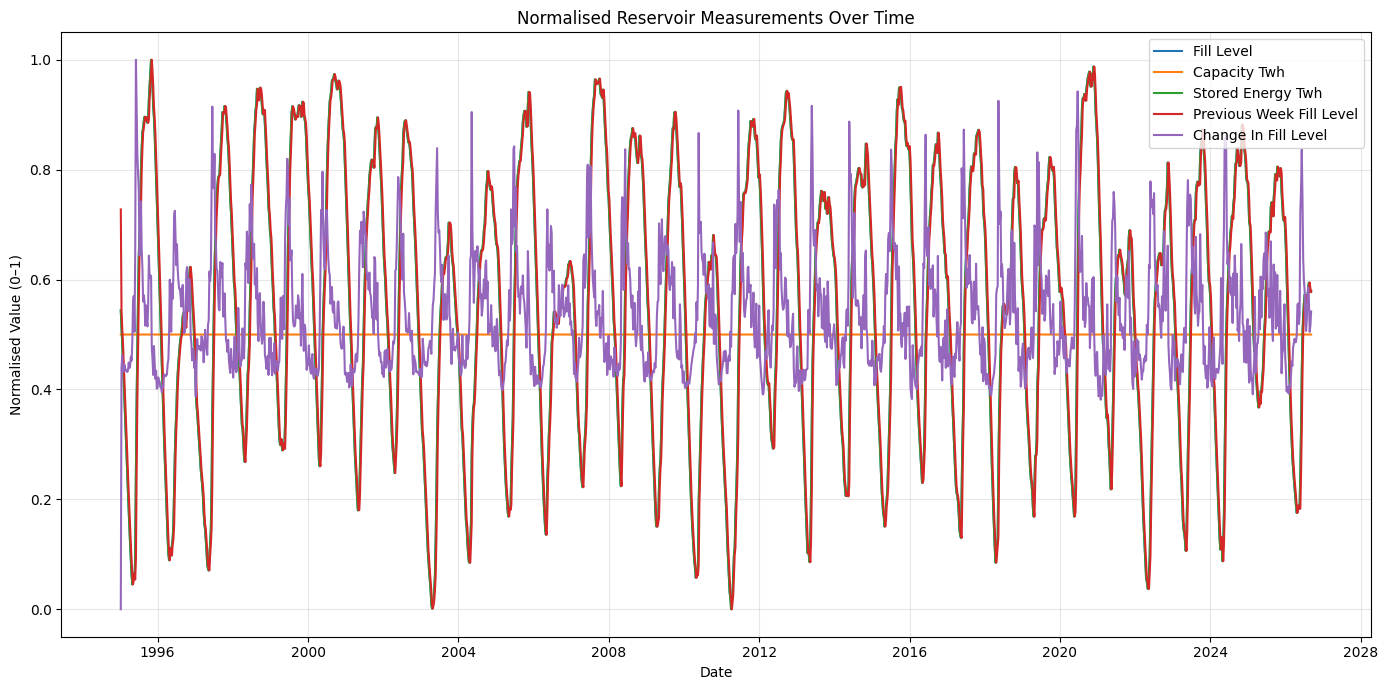

In [87]:
# Plot all normalised reservoir measurements on the same scale.
plt.figure(figsize=(14, 7))

for column in measurement_columns:
    plt.plot(
        normalized_weekly_mean.index,
        normalized_weekly_mean[column],
        label=column.replace("_", " ").title()
    )

plt.title("Normalised Reservoir Measurements Over Time")
plt.xlabel("Date")
plt.ylabel("Normalised Value (0–1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Derived Time Variables

The dataset already contains year and ISO week information.

For exploratory purposes, the calendar month is also derived from the date.
This is useful for monthly filtering and will later support the month-selection
functionality in the Streamlit application.

In [88]:
# Derive month information from the observation date.
reservior_df["month_number"] = reservior_df["date"].dt.month
reservior_df["month_name"] = reservior_df["date"].dt.month_name()

# Inspect the derived variables.
reservior_df[["date", "year", "week", "month_number", "month_name"]].head()

,date,year,week,month_number,month_name
0,1995-01-08,1995,1,1,January
1,1995-01-08,1995,1,1,January
2,1995-01-08,1995,1,1,January
3,1995-01-08,1995,1,1,January
4,1995-01-08,1995,1,1,January


### 13.1 Monthly Reservoir Patterns

To obtain a high-level view of seasonality, reservoir measurements are averaged
by calendar month.

This summary does not replace the weekly data; it provides an additional view
of typical changes across the year.

In [89]:
# Calculate average reservoir measurements for each calendar month.
monthly_summary = (
    reservior_df.groupby("month_number")[measurement_columns]
    .mean()
    .sort_index()
)

monthly_summary

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
month_number,,,,,
1,0.619034,29.14586,18.325756,0.645800,-0.026766
2,0.497810,29.14586,14.987228,0.526443,-0.028633
3,0.385994,29.14586,11.882482,0.410784,-0.024790
4,0.307788,29.14586,9.649319,0.319067,-0.011280
5,0.359926,29.14586,10.829130,0.329886,0.030039
6,0.571342,29.14586,16.533804,0.520873,0.050469
7,0.727570,29.14586,20.938909,0.701431,0.026139
8,0.788875,29.14586,22.696154,0.780162,0.008713
9,0.816625,29.14586,23.528835,0.811896,0.004729


## 14. Data Quality Summary

The dataset was inspected for common data-quality issues before being used in
the visualisations.
For
- missing values,
- duplicate observations,
- appropriate date types,
- chronological ordering,
- and sensible numerical summaries.

The original dataset contains placeholder publication dates represented by `0001-01-01T00:00:00`.

These values were replaced with missing values during data preparation because they do not appear to represent actual publication dates.

The missing-value summary therefore includes missing publication dates. The observation dates and continuous reservoir measurements are retained for the analysis.


In [90]:
# Produce a compact data-quality summary.
quality_summary = pd.DataFrame({
    "data_type": reservior_df.dtypes.astype(str),
    "missing_values": reservior_df.isna().sum(),
    "unique_values": reservior_df.nunique()
})

quality_summary

,data_type,missing_values,unique_values
date,datetime64[ns],0,1653
area_type,object,0,3
area_number,int64,0,6
year,int64,0,32
week,int64,0,53
fill_level,float64,0,14868
capacity_TWh,float64,0,9
stored_energy_TWh,float64,0,14871
next_publication_date,datetime64[ns],11322,395
previous_week_fill_level,float64,0,14868



## 15. Log

The development of this project started with importing the `reservoirs.csv` dataset into a Jupyter Notebook using Pandas. The first step was to examine the dataset to understand its structure, data types, missing values, and geographical coverage. The dataset contains 14,877 observations covering the period from 1995 to 2026. I translated the original Norwegian column names into clear and descriptive English labels and converted the observation dates to datetime format to facilitate further analysis. I also identified placeholder values in the publication-date column and replaced them with missing values to prevent them from being interpreted as valid dates.

During the exploratory data analysis, I examined the numerical variables and created individual plots to investigate their distributions and changes over time. A key challenge was the difference in scales between the measurements. For example, fill level is represented as a proportion, whereas capacity and stored energy are measured in TWh. Plotting these variables directly on the same axis made it difficult to compare their patterns. To address this, I used Min-Max normalisation for the combined visualisation. Constant variables were also handled separately to prevent division-by-zero errors. The analysis showed that national fill level and stored energy have very similar normalised patterns, which is expected because stored energy is related to both fill level and reservoir capacity.

After completing the notebook analysis, I developed ReservoirScope as a multi-page Streamlit application. The application consists of four pages: Home, Reservoir Data, Reservoir Visualisation, and Project Information. The Reservoir Data page displays the imported dataset and the first-month measurements using Streamlit's `LineChartColumn()`. The Reservoir Visualisation page allows users to select a measurement using `st.selectbox()` and specify a date range using `st.select_slider()`. It also includes a combined normalised plot that enables users to compare measurements with different scales.

To improve application performance, I used `st.cache_data` to avoid repeatedly loading the CSV file. Matplotlib was used to customise the visualisations, while Streamlit's theme configuration was used to provide a consistent appearance throughout the application. During development, I also adjusted the plotting order and line styles because some normalised measurements overlapped, making certain lines difficult to distinguish.

GitHub was used for version control and for organising the notebook, application files, and project dependencies. The application was subsequently deployed using Streamlit Community Cloud, making it accessible online. I tested the different pages, visualisations, and interactive controls to ensure that the deployed application worked as intended.

Overall, this project provided practical experience in connecting exploratory data analysis with interactive application development. It strengthened my understanding of real-world data preparation, visualisation techniques, numerical scaling, and Python project organisation. It also highlighted the importance of carefully evaluating visualisations to ensure that they accurately represent the underlying data and do not create misleading comparisons.


## 16. Conclusion
This notebook documents the preparation and exploratory analysis of the reservoir dataset used in this project.

The raw data were inspected and processed by replacing the original column names with clear English labels, converting variables to appropriate data types, and checking for missing and duplicate observations. Exploratory analysis was then conducted to examine the geographical, temporal, and numerical characteristics of the dataset.

Individual reservoir measurements were visualised separately to understand their distributions and trends over time. Since the measurements use different scales, normalisation was applied to enable meaningful comparison in a combined visualisation.

The resulting data preparation and exploratory analysis form the foundation of the interactive ReservoirScope Streamlit application. The completed analysis supports the deployed application, where users can explore reservoir measurements through interactive tables, filtering options, and time-series visualisations.
